# Assignment 4 Build a classifier

Building a Classifier I Can Defend Heart Disease Dataset using Random Forest

In [53]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("../data/processed/heart_disease_cleaned.csv")

# Display the first five rows
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Mean_Age,Mean_Cholesterol,Cholesterol_Z
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,7.633228,Medium,342.0,120.0,12.969246,12.387250,No,49.139387,224.882119,-1.618712
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,8.744034,Medium,133.0,157.0,9.355389,19.298875,No,49.452792,225.977300,1.392213
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,4.440440,Low,393.0,92.0,12.709873,11.230926,No,49.139387,224.882119,-0.216679
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,5.249405,High,293.0,94.0,12.509046,5.961958,No,49.452792,225.977300,1.553102
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,7.030971,High,263.0,154.0,10.381259,8.153887,No,49.139387,224.882119,0.380910


In [54]:
#Check the cleaned dataset
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (10000, 24)

Columns:
['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level', 'Heart Disease Status', 'Mean_Age', 'Mean_Cholesterol', 'Cholesterol_Z']

Missing values:
Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      

In [55]:
# Convert Heart Disease Status into a numerical target

df["Heart_Disease_Target"] = df["Heart Disease Status"].map({
    "No": 0,
    "Yes": 1
})

print(df[["Heart Disease Status", "Heart_Disease_Target"]].head())

  Heart Disease Status  Heart_Disease_Target
0                   No                     0
1                   No                     0
2                   No                     0
3                   No                     0
4                   No                     0


In [56]:
# #Select the same features for both models
numerical_features = [
    "Age",
    "Blood Pressure",
    "Cholesterol Level",
    "BMI",
    "Sleep Hours",
    "Triglyceride Level",
    "Fasting Blood Sugar",
    "CRP Level",
    "Homocysteine Level"
]

# Categorical features
categorical_features = [
    "Gender",
    "Exercise Habits",
    "Smoking",
    "Family Heart Disease",
    "Diabetes",
    "High Blood Pressure",
    "Low HDL Cholesterol",
    "High LDL Cholesterol",
    "Alcohol Consumption",
    "Stress Level",
    "Sugar Consumption"
]

# Combine features
features = numerical_features + categorical_features

X = df[features].copy()

y = df["Heart_Disease_Target"]

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 20
X shape: (10000, 20)
y shape: (10000,)


In [57]:
missing = X.isna().sum()

print(missing[missing > 0])

Series([], dtype: int64)


 Train-Test Split

I split the dataset into 80% training data and 20% testing data. The training data will be used to train the models, while the testing data will be used to evaluate their performance. I use `stratify=y` to maintain the same proportion of heart disease cases in both datasets.

In [58]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (8000, 20)
Testing: (2000, 20)


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Numerical columns
numerical_features = [
    "Age",
    "Blood Pressure",
    "Cholesterol Level",
    "BMI",
    "Sleep Hours",
    "Triglyceride Level",
    "Fasting Blood Sugar",
    "CRP Level",
    "Homocysteine Level"
]

# Categorical columns
categorical_features = [
    "Gender",
    "Exercise Habits",
    "Smoking",
    "Family Heart Disease",
    "Diabetes",
    "High Blood Pressure",
    "Low HDL Cholesterol",
    "High LDL Cholesterol",
    "Alcohol Consumption",
    "Stress Level",
    "Sugar Consumption"
]

# Create the preprocessing step
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [60]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [61]:
rf_new_pred = rf_pipeline.predict(X_test)

print("Predictions completed.")
print(rf_new_pred[:20])

Predictions completed.
[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [62]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# Create a baseline that always predicts the most common class
baseline = DummyClassifier(strategy="most_frequent", random_state=42)

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

print("Baseline Accuracy:", round(
    accuracy_score(y_test, baseline_predictions), 4
))

print("Baseline Precision:", round(
    precision_score(y_test, baseline_predictions, zero_division=0), 4
))

print("Baseline Recall:", round(
    recall_score(y_test, baseline_predictions, zero_division=0), 4
))

print("Baseline F1:", round(
    f1_score(y_test, baseline_predictions, zero_division=0), 4
))

Baseline Accuracy: 0.8
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

new_accuracy = accuracy_score(
    y_test,
    rf_new_pred
)

new_precision = precision_score(
    y_test,
    rf_new_pred,
    zero_division=0
)

new_recall = recall_score(
    y_test,
    rf_new_pred,
    zero_division=0
)

new_f1 = f1_score(
    y_test,
    rf_new_pred,
    zero_division=0
)

print(f"Accuracy:  {new_accuracy:.4f}")
print(f"Precision: {new_precision:.4f}")
print(f"Recall:    {new_recall:.4f}")
print(f"F1 Score:  {new_f1:.4f}")

Accuracy:  0.7980
Precision: 0.2500
Recall:    0.0050
F1 Score:  0.0098


In [64]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_new_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ],
        zero_division=0
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.80      1.00      0.89      1600
   Heart Disease       0.25      0.01      0.01       400

        accuracy                           0.80      2000
       macro avg       0.53      0.50      0.45      2000
    weighted avg       0.69      0.80      0.71      2000



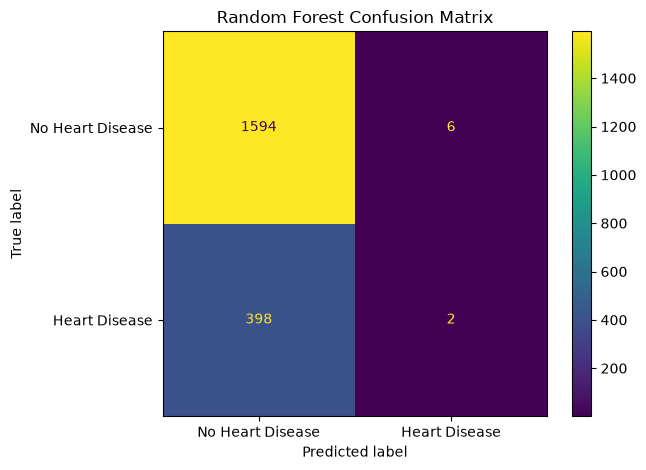

In [65]:
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_new_pred,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---- Baseline metrics ----
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions, zero_division=0)
baseline_recall = recall_score(y_test, baseline_predictions, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_predictions, zero_division=0)


# ---- Original Random Forest metrics ----
rf_accuracy = accuracy_score(y_test, rf_new_pred)
rf_precision = precision_score(y_test, rf_new_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_new_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_new_pred, zero_division=0)


# ---- Balanced Random Forest metrics ----
balanced_accuracy = accuracy_score(y_test, rf_balanced_pred)
balanced_precision = precision_score(y_test, rf_balanced_pred, zero_division=0)
balanced_recall = recall_score(y_test, rf_balanced_pred, zero_division=0)
balanced_f1 = f1_score(y_test, rf_balanced_pred, zero_division=0)


# ---- Improved Random Forest metrics ----
new_accuracy = accuracy_score(y_test, rf_new_pred)
new_precision = precision_score(y_test, rf_new_pred, zero_division=0)
new_recall = recall_score(y_test, rf_new_pred, zero_division=0)
new_f1 = f1_score(y_test, rf_new_pred, zero_division=0)


# ---- Create comparison table ----
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Original Random Forest",
        "Balanced Random Forest",
        "Improved Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        rf_accuracy,
        balanced_accuracy,
        new_accuracy
    ],
    "Precision": [
        baseline_precision,
        rf_precision,
        balanced_precision,
        new_precision
    ],
    "Recall": [
        baseline_recall,
        rf_recall,
        balanced_recall,
        new_recall
    ],
    "F1 Score": [
        baseline_f1,
        rf_f1,
        balanced_f1,
        new_f1
    ]
})

# Display results
comparison.round(4)

NameError: name 'rf_balanced_pred' is not defined

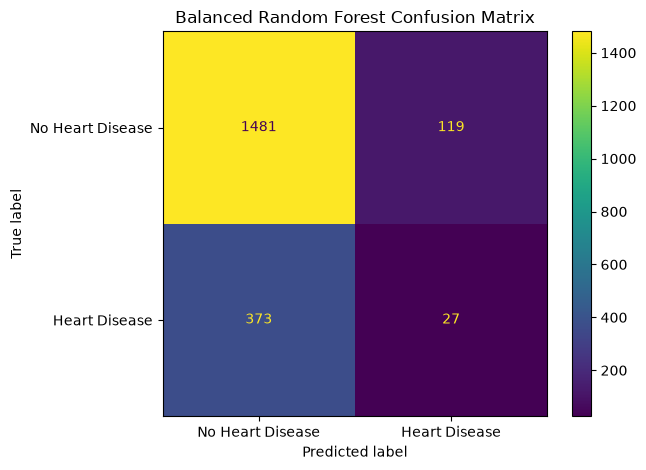

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_balanced_pred,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

plt.title("Balanced Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_balanced_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ],
        zero_division=0
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.80      0.93      0.86      1600
   Heart Disease       0.18      0.07      0.10       400

        accuracy                           0.75      2000
       macro avg       0.49      0.50      0.48      2000
    weighted avg       0.68      0.75      0.71      2000



In [ ]:
best_model = comparison.loc[
    comparison["F1 Score"].idxmax()
]

print("Best model based on F1 Score:")
print(best_model)

Best model based on F1 Score:
Model        Balanced Random Forest
Accuracy                      0.754
Precision                  0.184932
Recall                       0.0675
F1 Score                   0.098901
Name: 2, dtype: object


## Build a Classifier I Can Defend

1. Objective

The objective of this project was to build a machine-learning classifier that predicts whether a person has heart disease using health and lifestyle information from the Heart Disease dataset. The target variable contains two classes: No Heart Disease and Heart Disease. The dataset is imbalanced, with 80% of the records having no heart disease and 20% having heart disease.

2. Data Preparation and Approach

I first explored and cleaned the dataset by checking missing values, unique values, and the data types of the columns. I also investigated the missing values in Alcohol Consumption before deciding how to handle them. For modelling, I used numerical health features such as Age, Blood Pressure, Cholesterol Level, BMI, Sleep Hours, Triglyceride Level, Fasting Blood Sugar, CRP Level, and Homocysteine Level. I also included categorical health and lifestyle features such as Gender, Smoking, Diabetes, Exercise Habits, and Family Heart Disease. The categorical variables were converted into numerical form using OneHotEncoder.

I used an 80/20 train-test split with stratification so that the class distribution remained similar in the training and testing data.

3. Models and Results

| Model                      |   Accuracy |  Precision |    Recall |  F1 Score |
| -------------------------- | ---------: | ---------: | --------: | --------: |
| Baseline                   |     80.00% |      0.00% |     0.00% |     0.00% |
| Original Random Forest     |     80.05% |     57.14% |     1.00% |     1.97% |
| **Balanced Random Forest** | **75.40%** | **18.49%** | **6.75%** | **9.89%** |
| Improved Random Forest     |     79.80% |     25.00% |     0.50% |     0.98% |

The baseline achieved 80% accuracy, but it failed to identify any heart disease cases. This shows why accuracy alone is not enough for this dataset. The Original Random Forest had slightly higher accuracy, but its recall for Heart Disease was only 1%. I then used a Balanced Random Forest to give more attention to the minority class. Its accuracy decreased to 75.40%, but its recall increased to 6.75% and its F1 score increased to 9.89%. The Improved Random Forest using additional categorical features did not improve the minority-class performance.

4. Final Model and Defense

I selected the Balanced Random Forest as the best model among the models tested because it achieved the highest F1 score (9.89%) and highest recall (6.75%). I used F1 as the main metric because the dataset is imbalanced, while recall is important because a false negative means that a person with heart disease is predicted as having no heart disease.

However, the final F1 score is still low, especially for the Heart Disease class, which had 0.18 precision, 0.07 recall, and 0.10 F1. Therefore, I would not use this model for real clinical decisions. The result shows that the Balanced Random Forest was the strongest model in my experiment, but further feature engineering, better data quality, and additional modelling would be needed to develop a reliable heart disease prediction system.
